## Load required libraries

In [19]:
# Let me define the list of required packages
packages <- c("tidyverse", "mFilter", "forecast", "scales", "ggplot2")

# Checking and installing missing packages
new_packages <- packages[!(packages %in% installed.packages()[,"Package"])]
if(length(new_packages)) install.packages(new_packages, repos = "http://cran.us.r-project.org")

# Now load them
library(tidyverse)
library(mFilter)
library(forecast)
library(scales)
library(ggplot2)

print("All libraries loaded successfully!")

[1] "All libraries loaded successfully!"


## Define Paths 

In [3]:
base_dir <- "../../"
clean_data_path <- file.path(base_dir, "data", "cleaned")
gdp_file_path <- file.path(clean_data_path, "gdp.csv")

## Load and Pre-process Data


In [4]:
df_gdp <- read.csv(gdp_file_path, stringsAsFactors = FALSE)


## Cleaning the column names and remove commas from numbers


In [62]:
# 1. Load Libraries
library(tidyverse)
library(scales)

# 2. Re-define Paths (Ensure these match your actual folder structure)
base_dir <- "../../"
gdp_file <- file.path(base_dir, "data", "cleaned", "gdp.csv")

# 3. Load Data
df_raw <- read.csv(gdp_file, stringsAsFactors = FALSE)

# 4. Robust Cleaning (Using the Native R pipe |> and explicit column indexes)
# This avoids issues with weird dot-names like '..._'
df_gdp <- df_raw 

# Assign simple names based on column position to avoid "Object not found"
colnames(df_gdp)[1] <- "year"
colnames(df_gdp)[2] <- "nominal_gdp"
colnames(df_gdp)[3] <- "growth_rate"
colnames(df_gdp)[4] <- "real_gdp"

# Final Numeric Cleaning
df_gdp$nominal_gdp <- as.numeric(gsub(",", "", as.character(df_gdp$nominal_gdp)))
df_gdp$real_gdp    <- as.numeric(gsub(",", "", as.character(df_gdp$real_gdp)))
df_gdp$growth_rate <- as.numeric(gsub("%", "", as.character(df_gdp$growth_rate)))

# Sort by year
df_gdp <- df_gdp[order(df_gdp$year), ]

# Verify results
print("First 5 rows of cleaned data:")
head(df_gdp)
tail(df_gdp)

[1] "First 5 rows of cleaned data:"


,year,nominal_gdp,growth_rate,real_gdp
,<int>,<dbl>,<dbl>,<dbl>
25,2000,967838,0.0,982855
24,2001,1020022,3.8,1020111
23,2002,1035374,0.5,1025583
22,2003,1131783,2.9,1055658
21,2004,1274328,5.1,1109338
20,2005,1415823,5.7,1172784


,year,nominal_gdp,growth_rate,real_gdp
,<int>,<dbl>,<dbl>,<dbl>
6,2019,10237727,5.1,8756946
5,2020,10715070,-0.3,8733060
4,2021,12027662,7.6,9395942
3,2022,13489642,4.9,9852583
2,2023,15033612,5.6,10416148
1,2024,16224477,4.7,10908285


## 1: Growth Momentum & Volatility
To visualize the "speed" of the economy. We want to see how much the growth fluctuates year-over-year to identify periods of high performance versus external shocks (like 2020)

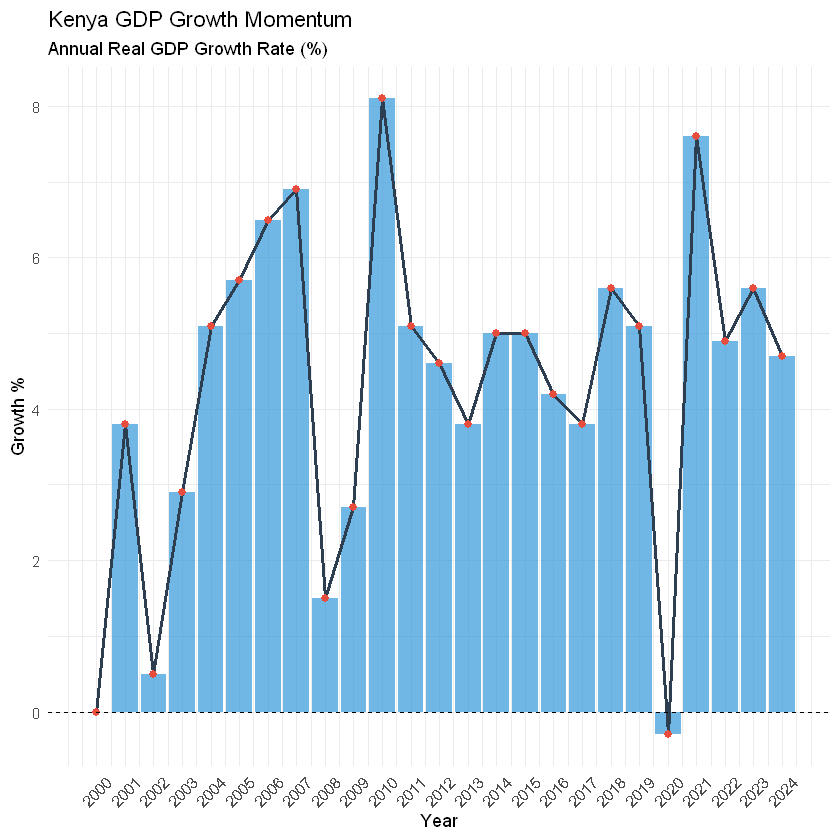

In [51]:
# Plotting the Growth Rate
ggplot(df_gdp, aes(x = year, y = growth_rate)) +
  geom_col(fill = "#3498db", alpha = 0.7) +
  geom_line(group = 1, color = "#2c3e50", size = 1) +
  geom_point(color = "#e74c3c", size = 2) +
  geom_hline(yintercept = 0, linetype = "dashed") +
  scale_x_continuous(breaks = df_gdp$year) +
  labs(title = "Kenya GDP Growth Momentum",
       subtitle = "Annual Real GDP Growth Rate (%)",
       y = "Growth %", x = "Year") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 0.5))

## 2: Trend vs. Cycle (The Output Gap)
I'll use the Hodrick-Prescott (HP) Filter to decompose Real GDP into two parts: a "Trend" (long-term potential) and a "Cycle" (short-term fluctuations).

#### Trend:
 The structural capacity of the economy.

#### Output Gap: 
The distance between the Actual line and the Trend line. If Actual is below Trend, the economy is underperforming.

#### Positive Gap: 
Economy is "overheating" (inflation risk).

#### Negative Gap: 
Economy is under-utilizing resources (unemployment/recession risk).

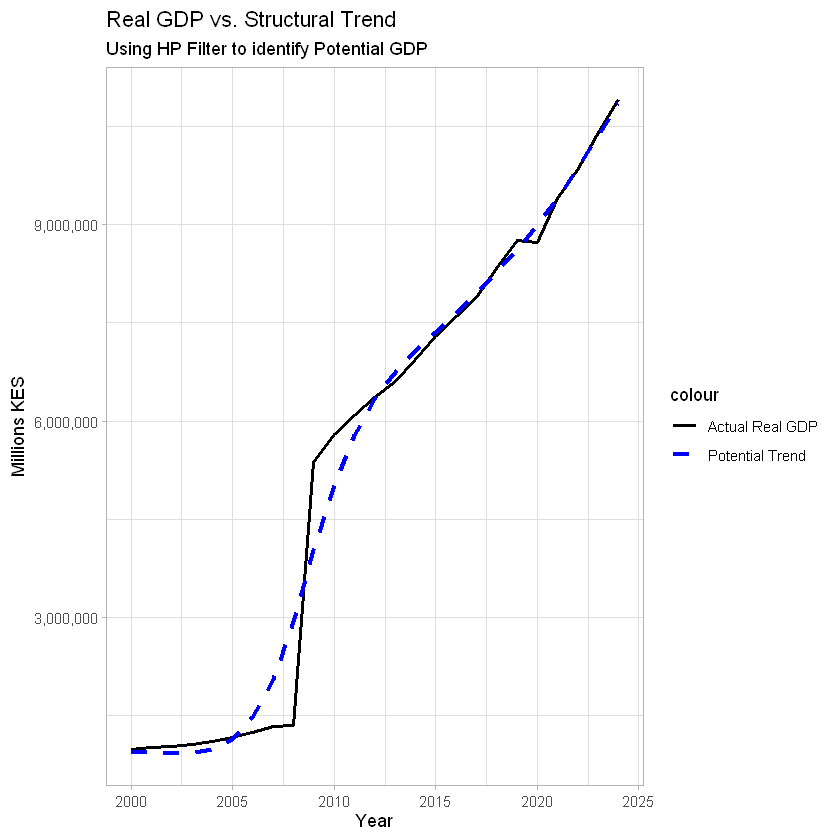

In [53]:
library(mFilter)

# Apply HP Filter (freq = 6.25 for annual data)
# We use the real_gdp column we cleaned earlier
hp_res <- mFilter::hpfilter(df_gdp$real_gdp, freq = 6.25)
df_gdp$potential_gdp <- as.numeric(hp_res$trend)

# Plotting Actual vs Potential
ggplot(df_gdp) +
  geom_line(aes(x = year, y = real_gdp, color = "Actual Real GDP"), size = 1) +
  geom_line(aes(x = year, y = potential_gdp, color = "Potential Trend"), linetype = "dashed", size = 1.2) +
  scale_color_manual(values = c("Actual Real GDP" = "black", "Potential Trend" = "blue")) +
  scale_y_continuous(labels = label_comma()) +
  labs(title = "Real GDP vs. Structural Trend",
       subtitle = "Using HP Filter to identify Potential GDP",
       y = "Millions KES", x = "Year") +
  theme_light()

## 3: The GDP Deflator (Inflation Proxy)
Let us calculate the difference between Nominal GDP (current prices) and Real GDP (inflation-adjusted). 
$$\text{GDP Deflator} = \left( \frac{\text{Nominal GDP}}{\text{Real GDP}} \right) \times 100$$
This gives us the Implicit GDP Deflator, which is the broadest measure of inflation because it includes everything produced in the country, not just the "basket of goods" used in CPI.
#### Why it matters: 
It shows how much "extra" money is being paid due to price increases rather than increased production.

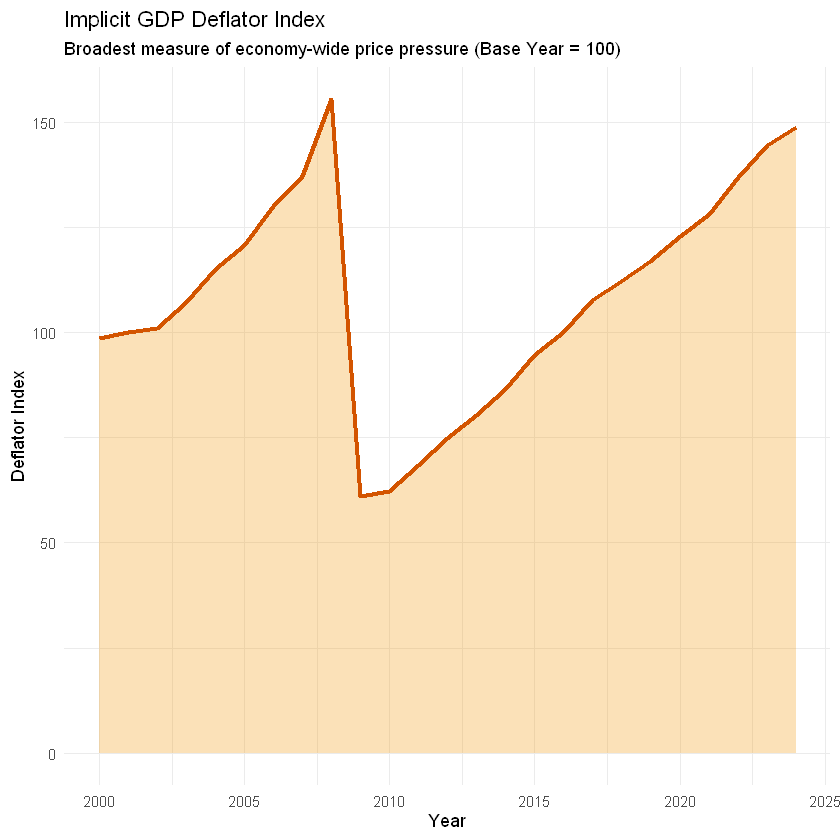

In [61]:
# We use dplyr::mutate to ensure the function is found
df_gdp <- df_gdp %>%
  dplyr::mutate(deflator = (nominal_gdp / real_gdp) * 100)

# Plotting the Deflator (Price Index)
ggplot(df_gdp, aes(x = year, y = deflator)) +
  geom_area(fill = "#f39c12", alpha = 0.3) +
  geom_line(color = "#d35400", size = 1.2) +
  labs(title = "Implicit GDP Deflator Index",
       subtitle = "Broadest measure of economy-wide price pressure (Base Year = 100)",
       y = "Deflator Index", x = "Year") +
  theme_minimal()

## 4. Forecasting (ARIMA Model)
I want to use historical patterns to project where the economy is headed in the next 5 years. 
Let's use an Auto-ARIMA model, which looks at past growth trends and seasonality to predict the most likely future path.

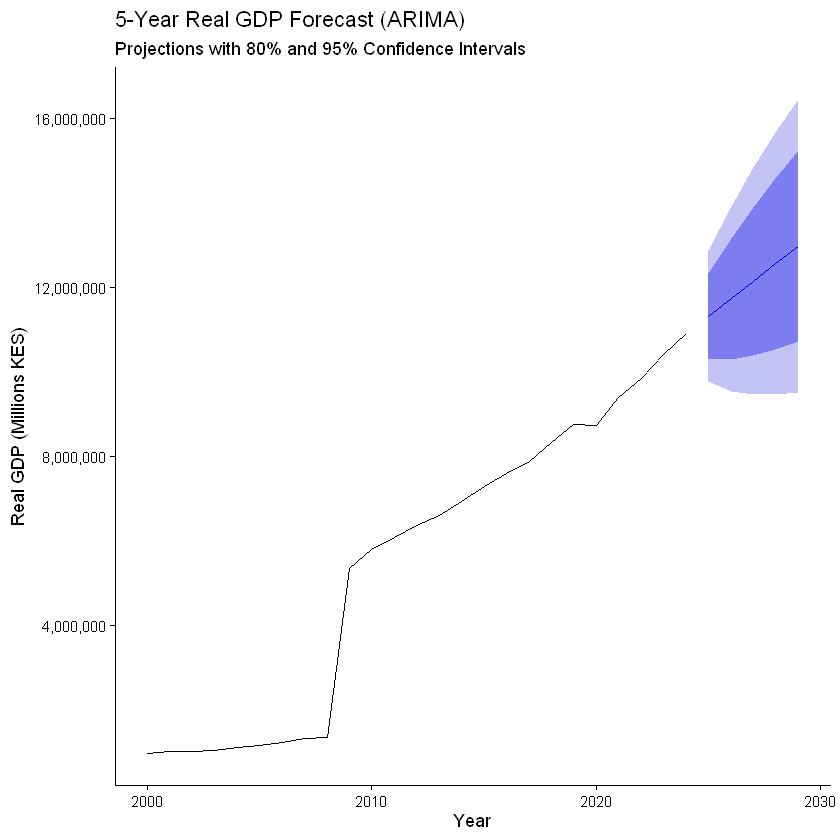

In [64]:
library(forecast)

# 1. Create a Time Series object
ts_gdp <- ts(df_gdp$real_gdp, start = min(df_gdp$year), frequency = 1)

# 2. Fit an Auto-ARIMA model
gdp_model <- forecast::auto.arima(ts_gdp)

# 3. Forecast 3 years into the future
gdp_forecast <- forecast::forecast(gdp_model, h = 5)

# 4. Plot
forecast::autoplot(gdp_forecast) +
  scale_y_continuous(labels = label_comma()) +
  labs(title = "5-Year Real GDP Forecast (ARIMA)",
       subtitle = "Projections with 80% and 95% Confidence Intervals",
       y = "Real GDP (Millions KES)", x = "Year") +
  theme_classic()

The blue shaded area in the forecast shows the "Confidence Interval" (the range of uncertainty).